# HW7 — Autoencoders on FashionMNIST: Fully Connected AE vs. Variational AE

**Personal parameters (Section 0.1):** SID4 = 1605 → SEED = 1605, SLICE = 605, HP_ID = 3, CLS_A = 5 (*Sandal*), CLS_B = 3 (*Dress*).

* **SEED** seeds the train/val split, all weight inits and the data order. Headline metrics are repeated over training seeds 1605, 1606 and 1607.
* **CLS_A / CLS_B** pick the two classes used in the latent-interpolation experiment (Sandal → Dress).
* **HP_ID / second hyper-parameter model:** not used. The assignment says this second configuration can be skipped because HW7 already compares two models.
* **SLICE:** not used by any HW7 task.

**Plan.** Both models use the same MLP encoder/decoder (784-512-256-**32**-256-512-784). Their reconstruction term is the same too: a Bernoulli log-likelihood, i.e. binary cross-entropy summed over the 784 pixels. The VAE differs in two ways: its encoder outputs a Gaussian $q(z\mid x)=\mathcal N(\mu,\operatorname{diag}\sigma^2)$, and its loss adds $\mathrm{KL}(q(z\mid x)\,\|\,\mathcal N(0,I))$. So any difference in the results comes from the variational objective, not from capacity.

**Evaluation:**
1. **Reconstruction** on the 10,000 test images: per-pixel MSE, BCE (nats/image), PSNR and SSIM. Also per-class MSE.
2. **Latent-space quality:** linear-probe accuracy on the 32-d codes, and a t-SNE map.
3. **Generation:** decode 10,000 random latent codes. These are scored with a separately trained FashionMNIST CNN, using a classifier-feature Fréchet distance ("C-FID", lower is better), an Inception-style score and the predicted-class distribution.
4. **Interpolation** between a Sandal (CLS_A) and a Dress (CLS_B).

In [1]:
import os, json, time, math, random, hashlib
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ---- Section 0.1 personal parameters (SID4 = 1605) ----
SID4, SEED, SLICE, HP_ID, CLS_A, CLS_B = 1605, 1605, 605, 3, 5, 3
SEEDS = [SEED, SEED + 1, SEED + 2]          # multi-seed repeats of the full training run
print(f"SID4={SID4} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")

# ---- shared hyper-parameters (identical for FC-AE and VAE) ----
LATENT, HIDDEN = 32, (512, 256)
EPOCHS, BATCH, LR = 30, 128, 1e-3
N_VAL = 6000
RETRAIN = os.environ.get("HW7_RETRAIN", "0") == "1"

SMOKE = os.environ.get("HW7_SMOKE", "0") == "1"   # 1-epoch pipeline check, writes to *_smoke dirs
DATA_DIR, CKPT_DIR, FIG_DIR, OUT_DIR = "data", "checkpoints", "figures", "outputs"
if SMOKE:
    EPOCHS = 1
    CKPT_DIR, FIG_DIR, OUT_DIR = [d + "_smoke" for d in (CKPT_DIR, FIG_DIR, OUT_DIR)]
for d in (CKPT_DIR, FIG_DIR, OUT_DIR):
    os.makedirs(d, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__, "| torchvision", torchvision.__version__)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

SID4=1605 SEED=1605 SLICE=605 HP_ID=3 CLS_A=5 CLS_B=3
device: mps | torch 2.11.0 | torchvision 0.26.0


## 1. Data
FashionMNIST: 60,000 train and 10,000 test images (28×28 grayscale, 10 classes). Pixels are scaled to [0, 1]. A seeded split (SEED = 1605) holds out 6,000 training images as a validation set for the learning curves. The test set is used only for the final evaluation.

train (54000, 784)  val (6000, 784)  test (10000, 784)


pixel range: 0.0 1.0 | train mean pixel: 0.2861
train class counts: [5408, 5417, 5425, 5379, 5391, 5387, 5442, 5378, 5363, 5410]


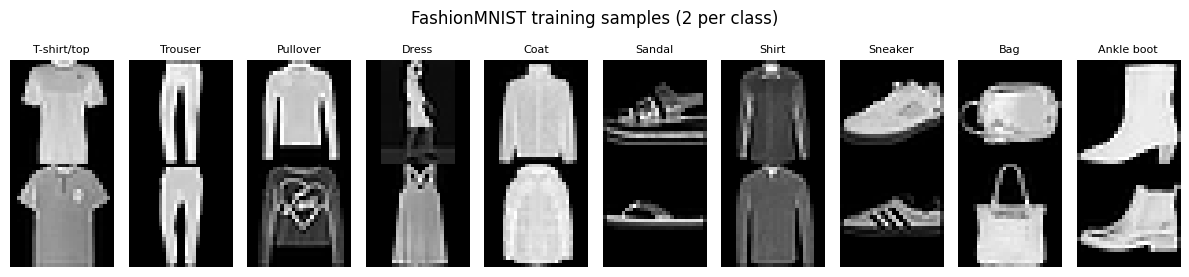

In [2]:
train_full = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True)
test_ds    = torchvision.datasets.FashionMNIST(DATA_DIR, train=False, download=True)
assert train_full.classes == CLASSES

X_full = train_full.data.float().div(255.).view(-1, 784)
y_full = train_full.targets.clone()
X_test = test_ds.data.float().div(255.).view(-1, 784)
y_test = test_ds.targets.clone()

perm = torch.randperm(len(X_full), generator=torch.Generator().manual_seed(SEED))
val_idx, tr_idx = perm[:N_VAL], perm[N_VAL:]
X_tr, y_tr = X_full[tr_idx], y_full[tr_idx]
X_val, y_val = X_full[val_idx], y_full[val_idx]
print(f"train {tuple(X_tr.shape)}  val {tuple(X_val.shape)}  test {tuple(X_test.shape)}")
print("pixel range:", X_tr.min().item(), X_tr.max().item(), "| train mean pixel:", round(X_tr.mean().item(), 4))
print("train class counts:", torch.bincount(y_tr).tolist())

# whole dataset fits on the GPU: no DataLoader needed
X_tr_d, X_val_d, X_test_d = X_tr.to(device), X_val.to(device), X_test.to(device)

fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for c in range(10):
    idx = (y_tr == c).nonzero()[:2, 0]
    for r in range(2):
        axes[r, c].imshow(X_tr[idx[r]].view(28, 28), cmap="gray"); axes[r, c].axis("off")
    axes[0, c].set_title(CLASSES[c], fontsize=8)
plt.suptitle("FashionMNIST training samples (2 per class)"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dataset_samples.png", dpi=120); plt.show()

## 2. Models

| | FC-AE | VAE |
|---|---|---|
| Encoder | 784→512→256→**32** (ReLU) | 784→512→256 → two heads: $\mu\in\mathbb R^{32}$, $\log\sigma^2\in\mathbb R^{32}$ |
| Latent | deterministic $z = f(x)$ | $z=\mu+\sigma\odot\varepsilon$, $\varepsilon\sim\mathcal N(0,I)$ (reparameterization trick) |
| Decoder | 32→256→512→784 (ReLU, logits) | same |
| Loss per image | $\mathrm{BCE}(x,\hat x)$ summed over pixels | $\mathrm{BCE}(x,\hat x) + \mathrm{KL}\big(\mathcal N(\mu,\sigma^2)\,\|\,\mathcal N(0,I)\big)$ = negative ELBO |

The decoder outputs logits and the loss uses `binary_cross_entropy_with_logits`, which is numerically stable. Reconstructed images are `sigmoid(logits)`. For the VAE, **reconstruction metrics decode the posterior mean $\mu$**, which is deterministic. The ELBO is estimated with one sampled $z$, as in training.

In [3]:
def mlp(sizes, last_act=False):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2 or last_act:
            layers.append(nn.ReLU())
    return nn.Sequential(*layers)

class FCAE(nn.Module):
    kind = "fcae"
    def __init__(self, latent=LATENT, hidden=HIDDEN):
        super().__init__()
        self.encoder = mlp([784, *hidden, latent])
        self.decoder = mlp([latent, *hidden[::-1], 784])
    def encode(self, x):
        return self.encoder(x)
    def decode(self, z):                      # returns logits
        return self.decoder(z)
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

class VAE(nn.Module):
    kind = "vae"
    def __init__(self, latent=LATENT, hidden=HIDDEN):
        super().__init__()
        self.body = mlp([784, *hidden], last_act=True)
        self.mu = nn.Linear(hidden[-1], latent)
        self.logvar = nn.Linear(hidden[-1], latent)
        self.decoder = mlp([latent, *hidden[::-1], 784])
    def encode(self, x):                      # posterior mean used as "the" code
        return self.mu(self.body(x))
    def encode_dist(self, x):
        h = self.body(x)
        return self.mu(h), self.logvar(h)
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode_dist(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar

def recon_bce(logits, x):        # nats per image
    return F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(1)

def kl_std_normal(mu, logvar):   # nats per image, closed form
    return 0.5 * (mu.pow(2) + logvar.exp() - 1.0 - logvar).sum(1)

for M in (FCAE, VAE):
    m = M()
    print(f"{M.__name__}: {sum(p.numel() for p in m.parameters()):,} parameters")
    print(m)

FCAE: 1,083,696 parameters
FCAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
  )
)
VAE: 1,091,920 parameters
VAE(
  (body): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=256, out_features=32, bias=True)
  (logvar): Linear(in_features=256, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, o

## 3. Evaluation helpers
**SSIM** is computed with the standard Gaussian-window formulation: an 11×11 window, σ = 1.5, $C_1=(0.01)^2$, $C_2=(0.03)^2$, valid convolution. It is averaged over the window positions and then over the images. **PSNR** is computed per image as $10\log_{10}(1/\mathrm{MSE}_i)$ and then averaged.

In [4]:
def _gauss_window(size=11, sigma=1.5):
    ax = torch.arange(size, dtype=torch.float32) - (size - 1) / 2
    g = torch.exp(-ax ** 2 / (2 * sigma ** 2)); g = g / g.sum()
    return (g[:, None] * g[None, :]).view(1, 1, size, size)

_WIN = _gauss_window().to(device)

def ssim_per_image(a, b):  # a, b: (B, 784) in [0,1]
    a, b = a.view(-1, 1, 28, 28), b.view(-1, 1, 28, 28)
    C1, C2 = 0.01 ** 2, 0.03 ** 2
    mu_a, mu_b = F.conv2d(a, _WIN), F.conv2d(b, _WIN)
    s_aa = F.conv2d(a * a, _WIN) - mu_a ** 2
    s_bb = F.conv2d(b * b, _WIN) - mu_b ** 2
    s_ab = F.conv2d(a * b, _WIN) - mu_a * mu_b
    m = ((2 * mu_a * mu_b + C1) * (2 * s_ab + C2)) / ((mu_a ** 2 + mu_b ** 2 + C1) * (s_aa + s_bb + C2))
    return m.flatten(1).mean(1)

# sanity: SSIM(x, x) must be 1
_x = X_val_d[:8]
assert torch.allclose(ssim_per_image(_x, _x), torch.ones(8, device=device), atol=1e-4)

@torch.no_grad()
def evaluate(model, X, bs=2000):
    # Returns dataset-mean metrics. For the VAE, reconstructions decode mu; ELBO uses one sampled z.
    model.eval()
    acc = {"bce": 0., "mse": 0., "psnr": 0., "ssim": 0., "kl": 0., "neg_elbo": 0.}
    for i in range(0, len(X), bs):
        x = X[i:i + bs]
        z = model.encode(x)
        logits = model.decode(z)
        xh = torch.sigmoid(logits)
        mse_i = (xh - x).pow(2).mean(1)
        acc["bce"] += recon_bce(logits, x).sum().item()
        acc["mse"] += mse_i.sum().item()
        acc["psnr"] += (10 * torch.log10(1.0 / mse_i.clamp_min(1e-10))).sum().item()
        acc["ssim"] += ssim_per_image(xh, x).sum().item()
        if model.kind == "vae":
            lg, mu, logvar = model(x)
            kl = kl_std_normal(mu, logvar)
            acc["kl"] += kl.sum().item()
            acc["neg_elbo"] += (recon_bce(lg, x) + kl).sum().item()
    out = {k: v / len(X) for k, v in acc.items()}
    if model.kind != "vae":
        out.pop("kl"); out.pop("neg_elbo")
    return out

## 4. Training
Both models are trained with Adam (lr 1e-3) for 30 epochs, batch size 128 (422 steps per epoch), on the 54,000-image training split. The validation metrics are logged after every epoch. Training is repeated for each seed in `SEEDS`. Checkpoints are written to `checkpoints/` and reloaded on later executions, unless `HW7_RETRAIN=1` is set.

In [5]:
def train_model(ModelCls, seed, log_every=5):
    set_seed(seed)
    model = ModelCls().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    g = torch.Generator().manual_seed(seed)
    n, hist, t0 = len(X_tr_d), [], time.time()
    for ep in range(1, EPOCHS + 1):
        model.train()
        order = torch.randperm(n, generator=g).to(device)
        tot = {"loss": 0., "bce": 0., "kl": 0.}
        for i in range(0, n, BATCH):
            x = X_tr_d[order[i:i + BATCH]]
            if model.kind == "vae":
                logits, mu, logvar = model(x)
                bce, kl = recon_bce(logits, x), kl_std_normal(mu, logvar)
                loss = (bce + kl).mean()
                tot["kl"] += kl.sum().item()
            else:
                logits, _ = model(x)
                bce = recon_bce(logits, x)
                loss = bce.mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            tot["loss"] += loss.item() * len(x); tot["bce"] += bce.sum().item()
        rec = {"epoch": ep, **{f"train_{k}": v / n for k, v in tot.items()}}
        rec.update({f"val_{k}": v for k, v in evaluate(model, X_val_d).items()})
        hist.append(rec)
        if ep == 1 or ep % log_every == 0:
            extra = f" kl {rec['val_kl']:.2f} -ELBO {rec['val_neg_elbo']:.2f}" if model.kind == "vae" else ""
            print(f"  [{model.kind} s{seed}] ep {ep:2d} train_loss {rec['train_loss']:.2f} | "
                  f"val bce {rec['val_bce']:.2f} mse {rec['val_mse']:.5f}{extra} | {time.time()-t0:.0f}s")
    return model, hist, time.time() - t0

def get_model(ModelCls, seed):
    path = f"{CKPT_DIR}/{ModelCls.kind}_seed{seed}.pt"
    if os.path.exists(path) and not RETRAIN:
        ck = torch.load(path, map_location=device)
        model = ModelCls().to(device); model.load_state_dict(ck["state_dict"]); model.eval()
        print(f"  loaded {path} (trained in {ck['train_seconds']:.0f}s)")
        return model, ck["history"], ck["train_seconds"]
    model, hist, secs = train_model(ModelCls, seed)
    torch.save({"state_dict": model.state_dict(), "history": hist, "train_seconds": secs,
                "config": {"latent": LATENT, "hidden": HIDDEN, "epochs": EPOCHS, "batch": BATCH,
                           "lr": LR, "seed": seed}}, path)
    return model.eval(), hist, secs

MODELS, HIST, SECS = {}, {}, {}
for seed in SEEDS:
    for M in (FCAE, VAE):
        MODELS[(M.kind, seed)], HIST[(M.kind, seed)], SECS[(M.kind, seed)] = get_model(M, seed)
json.dump({f"{k}_seed{s}": h for (k, s), h in HIST.items()}, open(f"{OUT_DIR}/histories.json", "w"), indent=1)

  loaded checkpoints/fcae_seed1605.pt (trained in 69s)
  loaded checkpoints/vae_seed1605.pt (trained in 86s)
  loaded checkpoints/fcae_seed1606.pt (trained in 66s)
  loaded checkpoints/vae_seed1606.pt (trained in 85s)
  loaded checkpoints/fcae_seed1607.pt (trained in 66s)
  loaded checkpoints/vae_seed1607.pt (trained in 86s)


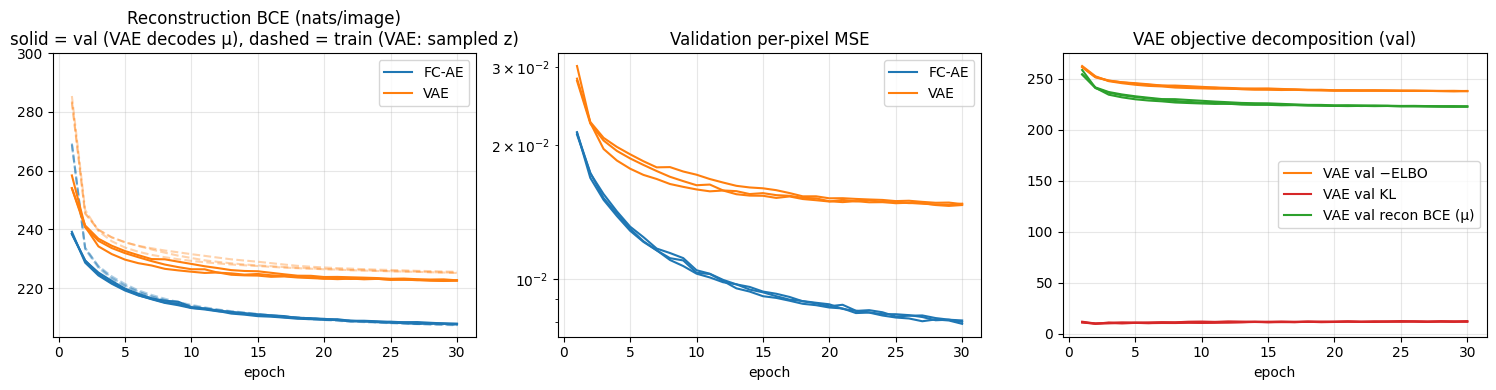

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for kind, col in (("fcae", "tab:blue"), ("vae", "tab:orange")):
    for j, seed in enumerate(SEEDS):
        h = pd.DataFrame(HIST[(kind, seed)])
        lab = kind.upper().replace("FCAE", "FC-AE") if j == 0 else None
        axes[0].plot(h.epoch, h.train_bce, color=col, alpha=.35, ls="--")
        axes[0].plot(h.epoch, h.val_bce, color=col, label=lab)
        axes[1].plot(h.epoch, h.val_mse, color=col, label=lab)
        if kind == "vae":
            axes[2].plot(h.epoch, h.val_neg_elbo, color="tab:orange", label="VAE val −ELBO" if j == 0 else None)
            axes[2].plot(h.epoch, h.val_kl, color="tab:red", label="VAE val KL" if j == 0 else None)
            axes[2].plot(h.epoch, h.val_bce, color="tab:green", label="VAE val recon BCE (μ)" if j == 0 else None)
axes[0].set_title("Reconstruction BCE (nats/image)\nsolid = val (VAE decodes μ), dashed = train (VAE: sampled z)"); axes[0].set_ylim(top=300)
axes[1].set_title("Validation per-pixel MSE"); axes[1].set_yscale("log")
axes[2].set_title("VAE objective decomposition (val)")
for a in axes: a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/training_curves.png", dpi=120); plt.show()

## 5. Test-set reconstruction metrics (3 seeds)

In [7]:
rows = []
for (kind, seed), m in MODELS.items():
    r = evaluate(m, X_test_d)
    rows.append({"model": kind, "seed": seed, **r, "train_min": SECS[(kind, seed)] / 60})
test_df = pd.DataFrame(rows)
test_df.to_csv(f"{OUT_DIR}/test_metrics_per_seed.csv", index=False)
display(test_df.round(5))

summary = test_df.drop(columns="seed").groupby("model").agg(["mean", "std"])
display(summary.round(5))

,model,seed,bce,mse,psnr,ssim,train_min,kl,neg_elbo
0,fcae,1605,209.91259,0.00813,22.08816,0.74603,1.14417,NaN,NaN
1,vae,1605,224.75785,0.01488,19.15742,0.64184,1.44084,11.88024,239.91132
2,fcae,1606,209.62177,0.00800,22.15453,0.74893,1.10125,NaN,NaN
3,vae,1606,224.78565,0.01487,19.16779,0.64340,1.42106,12.18281,239.87482
4,fcae,1607,209.80502,0.00809,22.10424,0.74769,1.10817,NaN,NaN
5,vae,1607,224.59847,0.01478,19.19274,0.63987,1.42777,12.51065,239.72950


bce               mse               psnr              ssim  \
            mean      std     mean      std      mean      std     mean   
model                                                                     
fcae   209.77980  0.14704  0.00807  0.00007  22.11564  0.03462  0.74755   
vae    224.71399  0.10100  0.01484  0.00006  19.17265  0.01815  0.64171   

               train_min                 kl            neg_elbo           
           std      mean      std      mean      std       mean      std  
model                                                                     
fcae   0.00145   1.11786  0.02304       NaN      NaN        NaN      NaN  
vae    0.00177   1.42989  0.01006  12.19123  0.31529  239.83855  0.09618

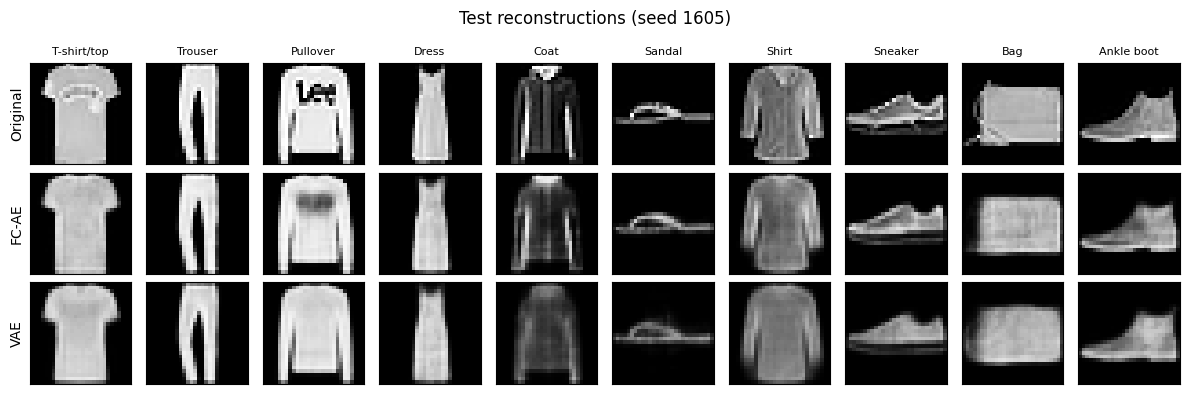

,fcae,vae,vae/fcae
T-shirt/top,0.00747,0.01436,1.92181
Trouser,0.00358,0.00754,2.10712
Pullover,0.00728,0.01456,2.00126
Dress,0.00735,0.01388,1.88793
Coat,0.00674,0.01351,2.00458
Sandal,0.01255,0.02190,1.74527
Shirt,0.00840,0.01472,1.75252
Sneaker,0.00597,0.01147,1.92294
Bag,0.01356,0.02181,1.60826
Ankle boot,0.00783,0.01468,1.87545


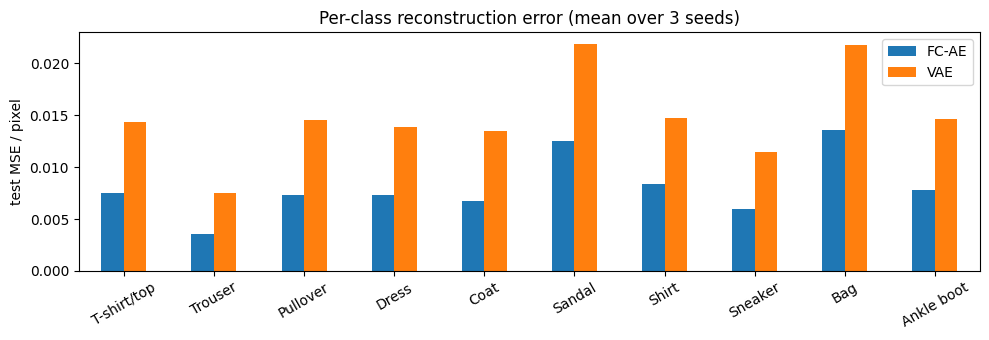

In [8]:
# qualitative reconstructions: first test image of each class, primary seed
fc, vae = MODELS[("fcae", SEED)], MODELS[("vae", SEED)]
idx = torch.stack([(y_test == c).nonzero()[0, 0] for c in range(10)])
x = X_test_d[idx]
with torch.no_grad():
    r_fc = torch.sigmoid(fc.decode(fc.encode(x))).cpu()
    r_vae = torch.sigmoid(vae.decode(vae.encode(x))).cpu()
fig, axes = plt.subplots(3, 10, figsize=(12, 4))
for c in range(10):
    for r, (img, name) in enumerate(((x.cpu(), "Original"), (r_fc, "FC-AE"), (r_vae, "VAE"))):
        axes[r, c].imshow(img[c].view(28, 28), cmap="gray", vmin=0, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if c == 0: axes[r, c].set_ylabel(name)
    axes[0, c].set_title(CLASSES[c], fontsize=8)
plt.suptitle(f"Test reconstructions (seed {SEED})"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reconstructions.png", dpi=120); plt.show()

# per-class test MSE, averaged over seeds
@torch.no_grad()
def per_image_mse(m, X):
    return (torch.sigmoid(m.decode(m.encode(X))) - X).pow(2).mean(1).cpu()

pc = {}
for kind in ("fcae", "vae"):
    per_seed = torch.stack([per_image_mse(MODELS[(kind, s)], X_test_d) for s in SEEDS]).mean(0)
    pc[kind] = [per_seed[y_test == c].mean().item() for c in range(10)]
pc_df = pd.DataFrame(pc, index=CLASSES); pc_df["vae/fcae"] = pc_df.vae / pc_df.fcae
display(pc_df.round(5))
ax = pc_df[["fcae", "vae"]].rename(columns={"fcae": "FC-AE", "vae": "VAE"}).plot.bar(figsize=(10, 3.5))
ax.set_ylabel("test MSE / pixel"); ax.set_title("Per-class reconstruction error (mean over 3 seeds)")
plt.xticks(rotation=30); plt.tight_layout(); plt.savefig(f"{FIG_DIR}/per_class_mse.png", dpi=120); plt.show()

## 6. Latent-space quality
A **linear probe** is a multinomial logistic regression trained on the 32-d codes of the 54,000 training images and scored on the 10,000 test codes. For the VAE the code is $\mu$. It measures how linearly separable the classes are in each latent space. A probe trained on raw pixels is included as a reference. The **t-SNE** map uses 3,000 test codes (seed 1605).

In [9]:
@torch.no_grad()
def codes(m, X, bs=5000):
    return torch.cat([m.encode(X[i:i + bs]) for i in range(0, len(X), bs)]).cpu().numpy()

def linear_probe(Ztr, ytr, Zte, yte):
    sc = StandardScaler().fit(Ztr)
    clf = LogisticRegression(max_iter=3000).fit(sc.transform(Ztr), ytr)
    return clf.score(sc.transform(Zte), yte), clf.score(sc.transform(Ztr), ytr)

probe_rows = []
for (kind, seed), m in MODELS.items():
    te_acc, tr_acc = linear_probe(codes(m, X_tr_d), y_tr.numpy(), codes(m, X_test_d), y_test.numpy())
    probe_rows.append({"model": kind, "seed": seed, "probe_test_acc": te_acc, "probe_train_acc": tr_acc})
t0 = time.time()
pix_te, pix_tr = linear_probe(X_tr.numpy(), y_tr.numpy(), X_test.numpy(), y_test.numpy())
probe_rows.append({"model": "raw pixels (784-d)", "seed": None, "probe_test_acc": pix_te, "probe_train_acc": pix_tr})
probe_df = pd.DataFrame(probe_rows); display(probe_df.round(4))
display(probe_df.dropna().groupby("model")[["probe_test_acc"]].agg(["mean", "std"]).round(4))

# VAE latent statistics: how many of the 32 dims are actually used?
with torch.no_grad():
    mu_te, lv_te = [t.cpu() for t in MODELS[("vae", SEED)].encode_dist(X_test_d)]
kl_per_dim = (0.5 * (mu_te.pow(2) + lv_te.exp() - 1 - lv_te)).mean(0)
active = int((kl_per_dim > 0.01).sum())
print(f"VAE seed {SEED}: active latent dims (mean KL > 0.01 nats) = {active}/32")
print("per-dim KL (sorted):", np.round(np.sort(kl_per_dim.numpy())[::-1], 3))
z_fc = codes(MODELS[("fcae", SEED)], X_test_d)
print(f"FC-AE seed {SEED}: latent per-dim std range {z_fc.std(0).min():.2f}–{z_fc.std(0).max():.2f}, "
      f"|mean| max {np.abs(z_fc.mean(0)).max():.2f}  (VAE mu std range {mu_te.std(0).min():.2f}–{mu_te.std(0).max():.2f})")

,model,seed,probe_test_acc,probe_train_acc
0,fcae,1605.0,0.8310,0.8429
1,vae,1605.0,0.8074,0.8213
2,fcae,1606.0,0.8313,0.8427
3,vae,1606.0,0.8036,0.8141
4,fcae,1607.0,0.8289,0.8404
5,vae,1607.0,0.8158,0.8254
6,raw pixels (784-d),NaN,0.8332,0.8894


probe_test_acc        
                mean     std
model                       
fcae          0.8304  0.0013
vae           0.8089  0.0062

VAE seed 1605: active latent dims (mean KL > 0.01 nats) = 6/32
per-dim KL (sorted): [2.723e+00 2.523e+00 2.001e+00 1.853e+00 1.612e+00 1.155e+00 1.000e-03
 1.000e-03 1.000e-03 1.000e-03 1.000e-03 1.000e-03 1.000e-03 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
FC-AE seed 1605: latent per-dim std range 0.97–2.65, |mean| max 2.27  (VAE mu std range 0.02–1.06)


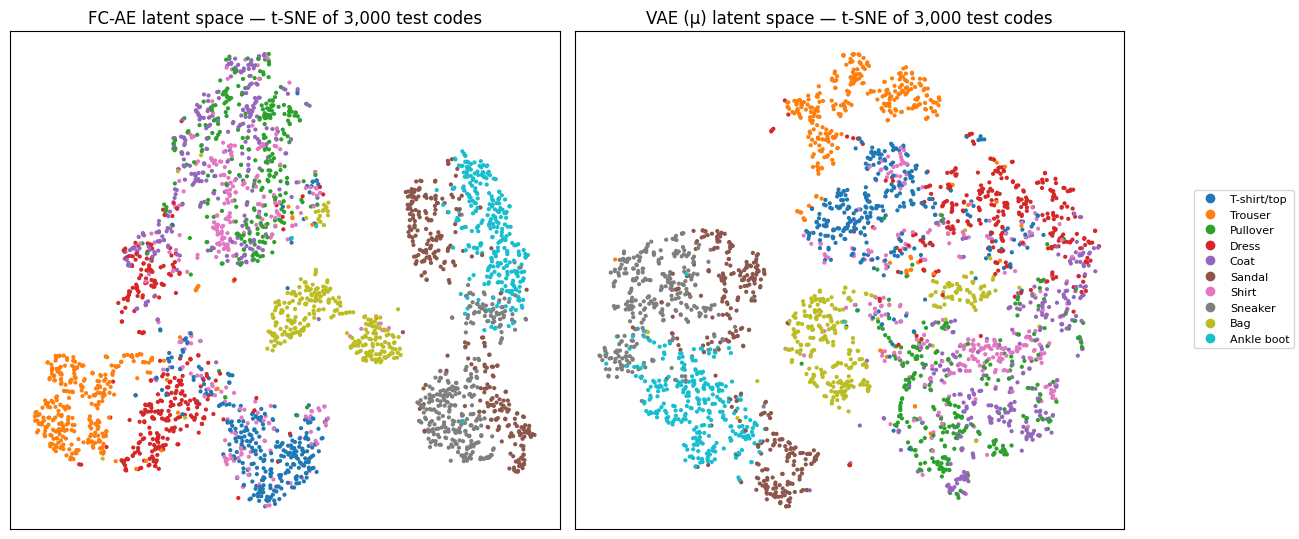

In [10]:
rng = np.random.default_rng(SEED)
sub = rng.choice(len(X_test), 3000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, kind, name in zip(axes, ("fcae", "vae"), ("FC-AE", "VAE (μ)")):
    Z = codes(MODELS[(kind, SEED)], X_test_d)[sub]
    E = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(Z)
    sc = ax.scatter(E[:, 0], E[:, 1], c=y_test.numpy()[sub], cmap="tab10", s=4)
    ax.set_title(f"{name} latent space — t-SNE of 3,000 test codes"); ax.set_xticks([]); ax.set_yticks([])
handles = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab10(c / 9), label=CLASSES[c]) for c in range(10)]
fig.legend(handles=handles, loc="center right", fontsize=8); plt.tight_layout(rect=(0, 0, .88, 1))
plt.savefig(f"{FIG_DIR}/latent_tsne.png", dpi=120); plt.show()

## 7. Generation from random latent codes
An autoencoder learns to *reconstruct*. Whether it can also *generate* depends on whether decoding a random latent code gives a realistic image. For each trained model, 10,000 codes are decoded:

* **VAE — prior:** $z\sim\mathcal N(0,I)$, the distribution the KL term pushed the posteriors toward.
* **FC-AE — N(0, I):** the same naive sampling. The FC-AE latent space was never regularized, so this tests the "no prior" failure mode.
* **FC-AE — Gaussian fit:** a stronger baseline. A full-covariance Gaussian is fitted to the FC-AE's training codes, and codes are sampled from it.

**Scoring.** A small CNN classifier is trained on the same 54k training split; its test accuracy is reported below. Its 128-d penultimate features give a **classifier Fréchet distance (C-FID)** between each sample set and the 10,000 real test images. A real-vs-real reference is also computed: 10,000 held-in training images vs. the test set. The classifier's softmax gives an **Inception-style score** $\exp\,\mathbb E_x\,\mathrm{KL}(p(y\mid x)\,\|\,p(y))$. This score is high only if samples are individually confident *and* diverse across classes; mode collapse lowers it. These are FashionMNIST-specific proxies, not the standard Inception-v3 FID.

In [11]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU())
        self.head = nn.Linear(128, 10)
    def features(self, x):
        return self.f(x.view(-1, 1, 28, 28))
    def forward(self, x):
        return self.head(self.features(x))

clf_path = f"{CKPT_DIR}/eval_classifier_cnn.pt"
clf = SmallCNN().to(device)
if os.path.exists(clf_path) and not RETRAIN:
    clf.load_state_dict(torch.load(clf_path, map_location=device)); print("loaded", clf_path)
else:
    set_seed(SEED); clf = SmallCNN().to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3); g = torch.Generator().manual_seed(SEED)
    y_tr_d = y_tr.to(device)
    for ep in range(8):
        clf.train(); order = torch.randperm(len(X_tr_d), generator=g).to(device)
        for i in range(0, len(order), 128):
            b = order[i:i + 128]
            loss = F.cross_entropy(clf(X_tr_d[b]), y_tr_d[b])
            opt.zero_grad(); loss.backward(); opt.step()
    torch.save(clf.state_dict(), clf_path)
clf.eval()

@torch.no_grad()
def clf_outputs(X, bs=2000):
    feats, probs = [], []
    for i in range(0, len(X), bs):
        f = clf.features(X[i:i + bs]); feats.append(f.cpu()); probs.append(F.softmax(clf.head(f), 1).cpu())
    return torch.cat(feats).double().numpy(), torch.cat(probs).double().numpy()

f_test, p_test = clf_outputs(X_test_d)
f_val, p_val = clf_outputs(X_val_d)
CLF_TEST_ACC = float((p_test.argmax(1) == y_test.numpy()).mean())
print(f"evaluation CNN: val acc {(p_val.argmax(1) == y_val.numpy()).mean():.4f}  test acc {CLF_TEST_ACC:.4f}")

# some ReLU feature dims are always 0 -> singular covariances; a small ridge keeps sqrtm stable (as in pytorch-fid)
FID_EPS = 1e-6
dead = int((f_test.std(0) == 0).sum()); print(f"dead (always-zero) CNN feature dims on test set: {dead}/128")
MU_TEST, COV_TEST = f_test.mean(0), np.cov(f_test, rowvar=False) + FID_EPS * np.eye(128)
def cfid(f):
    mu, cov = f.mean(0), np.cov(f, rowvar=False) + FID_EPS * np.eye(128)
    covmean = linalg.sqrtm(cov @ COV_TEST)
    assert np.isfinite(covmean).all()
    covmean = covmean.real
    return float(((mu - MU_TEST) ** 2).sum() + np.trace(cov + COV_TEST - 2 * covmean))

def inception_style(p, eps=1e-12):
    py = p.mean(0, keepdims=True)
    return float(np.exp((p * (np.log(p + eps) - np.log(py + eps))).sum(1).mean()))

def gen_scores(X):
    f, p = clf_outputs(X)
    hist = np.bincount(p.argmax(1), minlength=10) / len(p)
    ent = float(-(hist * np.log(hist + 1e-12)).sum() / np.log(10))   # 1.0 = perfectly uniform over classes
    return {"c_fid": cfid(f), "is_style": inception_style(p), "mean_max_conf": float(p.max(1).mean()),
            "class_entropy_norm": ent}, hist

real_ref_idx = torch.randperm(len(X_tr), generator=torch.Generator().manual_seed(SEED))[:10000]
real_scores, real_hist = gen_scores(X_tr_d[real_ref_idx])
print("real train images (reference):", {k: round(v, 3) for k, v in real_scores.items()})

loaded checkpoints/eval_classifier_cnn.pt


evaluation CNN: val acc 0.9162  test acc 0.9092
dead (always-zero) CNN feature dims on test set: 49/128


real train images (reference): {'c_fid': 0.5, 'is_style': 8.378, 'mean_max_conf': 0.935, 'class_entropy_norm': 0.999}


In [12]:
N_GEN = 10000

@torch.no_grad()
def sample(kind, seed, mode):
    m = MODELS[(kind, seed)]
    g = torch.Generator().manual_seed(seed)
    if mode == "gauss_fit":
        Z = torch.from_numpy(codes(m, X_tr_d)).double()
        mean, cov = Z.mean(0), torch.cov(Z.T)
        L = torch.linalg.cholesky(cov + 1e-6 * torch.eye(LATENT, dtype=torch.float64))
        z = (mean + torch.randn(N_GEN, LATENT, generator=g, dtype=torch.float64) @ L.T).float()
    else:
        z = torch.randn(N_GEN, LATENT, generator=g)
    return torch.sigmoid(m.decode(z.to(device)))

GEN_SETTINGS = [("vae", "prior", "VAE — N(0,I) prior"),
                ("fcae", "std_normal", "FC-AE — N(0,I)"),
                ("fcae", "gauss_fit", "FC-AE — Gaussian fit to train codes")]
gen_rows, gen_hists, gen_imgs = [], {}, {}
for kind, mode, name in GEN_SETTINGS:
    for seed in SEEDS:
        imgs = sample(kind, seed, mode)
        s, h = gen_scores(imgs)
        gen_rows.append({"setting": name, "seed": seed, **s})
        if seed == SEED:
            gen_hists[name], gen_imgs[name] = h, imgs[:40].cpu()
gen_rows.append({"setting": "Real train images (reference)", "seed": None, **real_scores})
gen_df = pd.DataFrame(gen_rows); display(gen_df.round(3))
gen_summary = gen_df.drop(columns="seed").groupby("setting", sort=False).agg(["mean", "std"])
display(gen_summary.round(3))

,setting,seed,c_fid,is_style,mean_max_conf,class_entropy_norm
0,"VAE — N(0,I) prior",1605.0,108.980,5.584,0.809,0.964
1,"VAE — N(0,I) prior",1606.0,114.036,5.514,0.802,0.965
2,"VAE — N(0,I) prior",1607.0,111.743,5.508,0.801,0.967
3,"FC-AE — N(0,I)",1605.0,216.689,3.148,0.651,0.888
4,"FC-AE — N(0,I)",1606.0,219.553,2.968,0.647,0.860
5,"FC-AE — N(0,I)",1607.0,233.888,2.912,0.610,0.901
6,FC-AE — Gaussian fit to train codes,1605.0,86.933,4.896,0.756,0.968
7,FC-AE — Gaussian fit to train codes,1606.0,96.537,4.784,0.752,0.964
8,FC-AE — Gaussian fit to train codes,1607.0,94.836,4.761,0.746,0.969
9,Real train images (reference),NaN,0.500,8.378,0.935,0.999


c_fid        is_style         \
                                        mean    std     mean    std   
setting                                                               
VAE — N(0,I) prior                   111.587  2.532    5.536  0.042   
FC-AE — N(0,I)                       223.377  9.215    3.009  0.123   
FC-AE — Gaussian fit to train codes   92.768  5.125    4.814  0.073   
Real train images (reference)          0.500    NaN    8.378    NaN   

                                    mean_max_conf        class_entropy_norm  \
                                             mean    std               mean   
setting                                                                       
VAE — N(0,I) prior                          0.804  0.004              0.965   
FC-AE — N(0,I)                              0.636  0.022              0.883   
FC-AE — Gaussian fit to train codes         0.752  0.005              0.967   
Real train images (reference)               0.935    NaN              0.999   

                                            
                                       std  
setting                                     
VAE — N(0,I) prior                   0.001  
FC-AE — N(0,I)                       0.021  
FC-AE — Gaussian fit to train codes  0.002  
Real train images (reference)          NaN

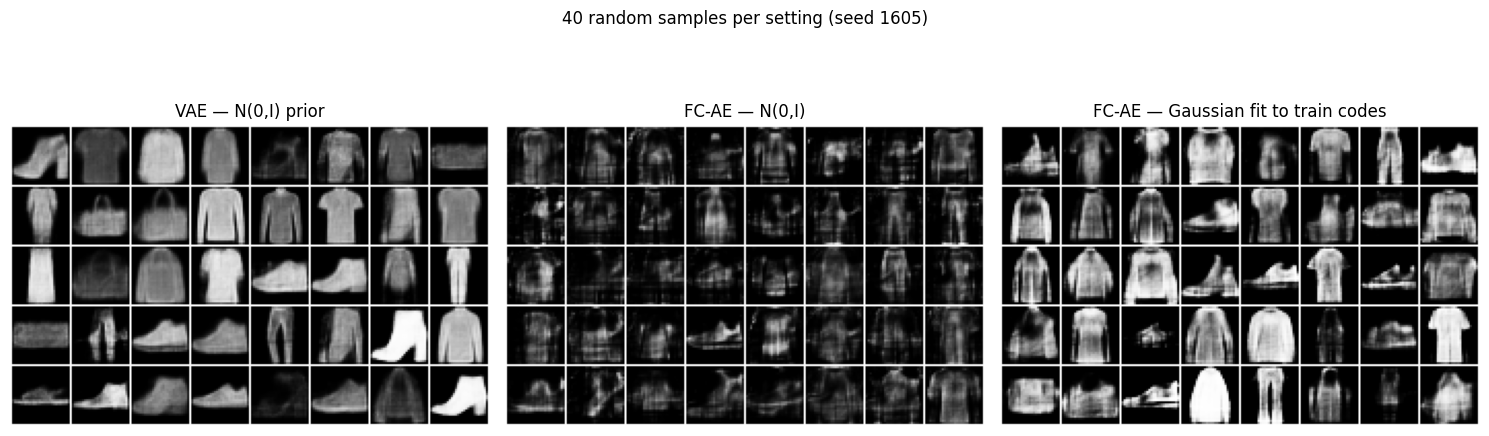

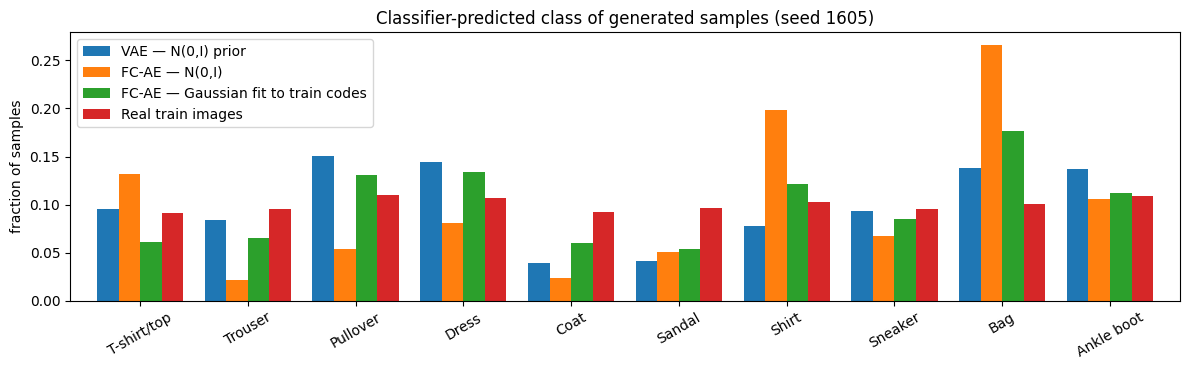

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (name, imgs) in zip(axes, gen_imgs.items()):
    grid = torchvision.utils.make_grid(imgs.view(-1, 1, 28, 28), nrow=8, padding=1, pad_value=1)
    ax.imshow(grid[0], cmap="gray", vmin=0, vmax=1); ax.set_title(name); ax.axis("off")
plt.suptitle(f"40 random samples per setting (seed {SEED})"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/generated_samples.png", dpi=120); plt.show()

hist_df = pd.DataFrame({**gen_hists, "Real train images": real_hist}, index=CLASSES)
ax = hist_df.plot.bar(figsize=(12, 3.8), width=.8)
ax.set_ylabel("fraction of samples"); ax.set_title(f"Classifier-predicted class of generated samples (seed {SEED})")
plt.xticks(rotation=30); plt.tight_layout(); plt.savefig(f"{FIG_DIR}/generated_class_hist.png", dpi=120); plt.show()

## 8. Latent interpolation: Sandal (CLS_A = 5) → Dress (CLS_B = 3)
The first test Sandal and the first test Dress are encoded. Their codes are linearly interpolated in 10 steps and each point is decoded. A smooth, plausible path means the latent space is continuous between the two classes; ghosted overlays or broken shapes mean it has holes.

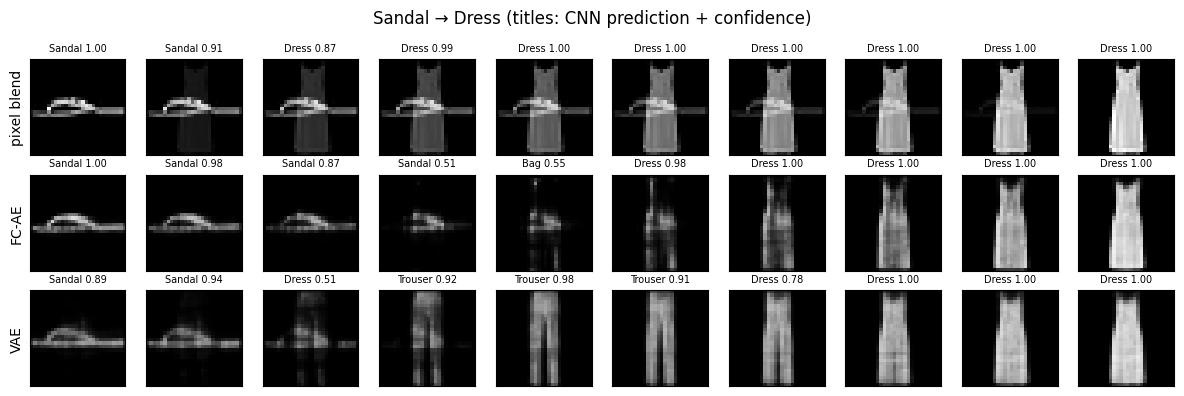

pixel blend  mean CNN confidence along path 0.977 | ['Sandal', 'Sandal', 'Dress', 'Dress', 'Dress', 'Dress', 'Dress', 'Dress', 'Dress', 'Dress']
FC-AE        mean CNN confidence along path 0.890 | ['Sandal', 'Sandal', 'Sandal', 'Sandal', 'Bag', 'Dress', 'Dress', 'Dress', 'Dress', 'Dress']
VAE          mean CNN confidence along path 0.894 | ['Sandal', 'Sandal', 'Dress', 'Trouser', 'Trouser', 'Trouser', 'Dress', 'Dress', 'Dress', 'Dress']


In [14]:
ia, ib = (y_test == CLS_A).nonzero()[0, 0], (y_test == CLS_B).nonzero()[0, 0]
alphas = torch.linspace(0, 1, 10, device=device)[:, None]
fig, axes = plt.subplots(3, 10, figsize=(12, 4))
with torch.no_grad():
    xa, xb = X_test_d[ia:ia + 1], X_test_d[ib:ib + 1]
    pix = (1 - alphas) * xa + alphas * xb
    rows_ = [("pixel blend", pix.cpu())]
    for kind, name in (("fcae", "FC-AE"), ("vae", "VAE")):
        m = MODELS[(kind, SEED)]
        za, zb = m.encode(xa), m.encode(xb)
        rows_.append((name, torch.sigmoid(m.decode((1 - alphas) * za + alphas * zb)).cpu()))
interp_conf = {}
for r, (name, imgs) in enumerate(rows_):
    _, p = clf_outputs(imgs.to(device))
    interp_conf[name] = {"pred": [CLASSES[i] for i in p.argmax(1)], "mean_max_conf": float(p.max(1).mean())}
    for c in range(10):
        axes[r, c].imshow(imgs[c].view(28, 28), cmap="gray", vmin=0, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        axes[r, c].set_title(f"{CLASSES[p[c].argmax()][:7]} {p[c].max():.2f}", fontsize=7)
        if c == 0: axes[r, c].set_ylabel(name)
plt.suptitle(f"{CLASSES[CLS_A]} → {CLASSES[CLS_B]} (titles: CNN prediction + confidence)"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/interpolation_sandal_to_dress.png", dpi=120); plt.show()
for k, v in interp_conf.items():
    print(f"{k:12s} mean CNN confidence along path {v['mean_max_conf']:.3f} | {v['pred']}")

In [15]:
def ms(df, col, key="model"):
    g = df.groupby(key)[col]
    return {k: {"mean": float(v.mean()), "std": float(v.std())} for k, v in g}

all_out = {
    "params": {"SID4": SID4, "SEED": SEED, "SEEDS": SEEDS, "SLICE": SLICE, "HP_ID": HP_ID,
               "CLS_A": CLS_A, "CLS_B": CLS_B, "latent": LATENT, "hidden": HIDDEN, "epochs": EPOCHS,
               "batch": BATCH, "lr": LR, "device": str(device), "torch": torch.__version__},
    "test_metrics_per_seed": test_df.to_dict("records"),
    "test_metrics_summary": {c: ms(test_df, c) for c in ["bce", "mse", "psnr", "ssim", "kl", "neg_elbo", "train_min"]},
    "per_class_mse": pc_df.to_dict(),
    "linear_probe": probe_df.to_dict("records"),
    "vae_active_dims_seed1605": active,
    "eval_classifier_test_acc": CLF_TEST_ACC,
    "generation_per_seed": gen_df.to_dict("records"),
    "generation_summary": {c: ms(gen_df, c, "setting") for c in ["c_fid", "is_style", "mean_max_conf", "class_entropy_norm"]},
    "generation_class_hist_seed1605": hist_df.to_dict(),
    "interpolation": interp_conf,
}
json.dump(all_out, open(f"{OUT_DIR}/all_outputs.json", "w"), indent=1, default=float)
print("wrote", f"{OUT_DIR}/all_outputs.json")

wrote outputs/all_outputs.json


## 9. Comparison and discussion

All numbers below come from the outputs above. They are means ± std over training seeds 1605/1606/1607 unless a seed is named.

### Reconstruction: FC-AE wins clearly

| Test set (10,000 images) | FC-AE | VAE |
|---|---|---|
| MSE / pixel | **0.00807 ± 0.00007** | 0.01484 ± 0.00006 |
| PSNR (dB) | **22.12 ± 0.03** | 19.17 ± 0.02 |
| SSIM | **0.748 ± 0.001** | 0.642 ± 0.002 |
| BCE (nats/image) | **209.78 ± 0.15** | 224.71 ± 0.10 |
| KL (nats/image) | — | 12.19 ± 0.32 |
| −ELBO (nats/image) | — | 239.84 ± 0.10 |

* The two models have the same architecture and the same reconstruction loss. Even so, the VAE's MSE is **1.84× higher**, and 1.6–2.1× higher in every class (per-class table). Both models find **Bag** and **Sandal** hardest: thin straps, prints and handle shapes vary a lot between items. **Trouser** is easiest.
* The reconstruction grid shows *how* they differ. FC-AE reconstructions keep stripes, the pullover logo region and the sandal straps. VAE reconstructions are smoother "prototype" garments, with the coat's texture and the shirt's buttons averaged away.
* **Why.** The KL term charges ~12 nats for every bit of information the code carries. The model responds by switching most latent dimensions off: only **6 of 32** dims have KL > 0.01 nats (seed 1605); the other 26 output $\mu\approx0$, $\sigma\approx1$ and carry no information. So the VAE effectively compresses through a **6-d** bottleneck, against 32 for the FC-AE. That is the classic rate–distortion trade-off of the ELBO, sometimes called partial posterior collapse. It was *not* visible after one epoch: the smoke test showed 31/32 dims active, so the pruning happens during training.
* Neither model overfits: train and validation BCE track each other for 30 epochs. The VAE's dashed "train" curve sits above its validation curve because training decodes a *sampled* z while validation decodes μ.

### Latent space: FC-AE codes are more linearly separable; VAE codes are smoother

* Linear-probe test accuracy: **FC-AE 83.0 ± 0.1%**, VAE 80.9 ± 0.6%, raw 784-d pixels 83.3%. The FC-AE's 32-d code keeps almost all of the linearly available class information in the pixels. The VAE loses ~2 points, consistent with its 6 active dims.
* In the t-SNE map, the FC-AE forms tighter, more separated islands, e.g. Bag and the footwear group. The VAE map is one more continuous sheet. Tops (T-shirt/Pullover/Coat/Shirt) blend into each other, and footwear forms a connected Sneaker–Sandal–Ankle-boot region.

### Generation: the VAE is a generative model; the plain FC-AE is not, unless you add a density model

| 10,000 samples, scored by a 90.9%-accurate FashionMNIST CNN | C-FID ↓ | IS-style ↑ | mean max-conf ↑ | class entropy ↑ |
|---|---|---|---|---|
| Real train images (reference) | 0.5 | 8.38 | 0.935 | 0.999 |
| **VAE, z ~ N(0, I)** | 111.6 ± 2.5 | **5.54 ± 0.04** | **0.804** | 0.965 |
| FC-AE, z ~ N(0, I) | 223.4 ± 9.2 | 3.01 ± 0.12 | 0.636 | 0.883 |
| FC-AE, z ~ Gaussian fitted to train codes | **92.8 ± 5.1** | 4.81 ± 0.07 | 0.752 | 0.967 |

* **Naive sampling separates the two models cleanly.** Decoding N(0, I) noise through the FC-AE gives textured, half-formed garments: C-FID 2× worse and IS-style 3.0 vs 5.5. The FC-AE's latent space was never shaped to match any prior; its per-dim std ranges from 0.97 to 2.65, with offset means. The VAE's KL term makes N(0, I) a valid sampling distribution by construction, and its samples are clean, recognisable garments.
* **The FC-AE gap is mostly about *where* to sample, not about the decoder.** If a full-covariance Gaussian is fitted to the FC-AE's training codes, its samples get the **best C-FID (92.8)**: their feature statistics, including texture detail, are closer to real data. But they are less often confidently one class (0.75 vs 0.80 confidence, IS 4.8 vs 5.5), and the grid shows more broken shapes. The VAE trades sharpness for samples that are reliably "on-manifold". This is why VAE samples look blurry yet clean.
* **No mode collapse in either model**, but neither covers the classes evenly. Normalised predicted-class entropy is 0.965 (VAE) and 0.967 (FC-AE fit), against 0.999 for real data. The VAE under-produces **Coat (4.0%)** and **Sandal (4.2%)**, against ~9–10% for real data, and over-produces Pullover/Dress/Bag/Ankle boot. Sandals are thin and high-frequency, so a blurry decoder rarely produces one that the CNN accepts. This is the VAE's *mode-averaging* behaviour, the mirror image of a GAN's mode dropping (report Part 2).

### Interpolation Sandal (CLS_A = 5) → Dress (CLS_B = 3)

* **Pixel blend:** a cross-fade where a dress and a sandal are overlaid. The CNN is still very confident (0.977), which shows that classifier confidence is not a realism metric on its own.
* **FC-AE:** keeps the sandal for 4 frames, then passes through faint, nearly empty frames (CNN: *Sandal 0.51*, *Bag 0.55*) before a dress appears. Straight lines between FC-AE codes cross low-density "holes" that the decoder never learned to fill.
* **VAE:** every frame is a plausible garment. The path runs Sandal → (Dress 0.51) → **Trouser ×3** → Dress, i.e. it walks *through* another class region instead of fading. This is what the KL prior buys: the space between codes is filled with decodable points, so the latent space is continuous.

### Bottom line
For **compression and reconstruction**, the FC-AE is better on every metric (1.8× lower MSE, +2.9 dB PSNR, +0.11 SSIM) and gives more linearly separable features. For **generation and smooth latent traversal**, the VAE is the right model: sampling from its prior works by construction, and its interpolations stay on the data manifold. Its price is blurrier reconstructions and a latent space where 26 of 32 dims go unused. An FC-AE can be made competitive at sampling with a post-hoc density on its codes, but then the sampling distribution is fitted after training rather than built into the objective.